# Lecture 4b — Five portfolios, not a million

**AI-powered Investment and Risk Management · Robo-Advisers and Automated Investment Platforms**

---

## The question

Notebook 4a left every client sorted into one of five buckets. This notebook asks what happens
next.

A robo-adviser with fifty thousand clients could, in principle, solve fifty thousand
optimisation problems — one per client, tuned exactly to their risk aversion. It has the data.
It has the compute; each problem takes milliseconds. Instead, essentially every platform in the
market runs the optimiser **offline**, a handful of times, on inputs set by an investment
committee, and hands each client the nearest of five or six pre-computed portfolios.

The obvious reading is that this is laziness dressed up as prudence. This notebook asks:

> **Is the model-portfolio ladder a shortcut, or is it the right answer?**

We will price the alternative. The answer turns out to be emphatic, and it arrives from a
direction most students do not expect: per-client optimisation is not merely unnecessary, it
is optimising a term roughly a hundred times smaller than the error already sitting in the
inputs.

## The layer

This is the **allocation** layer — the third of the six, and the one at the centre of the
lecture's thesis. It is the layer where all the money sits and, as the scoreboard slide claims,
the layer where there is no machine learning at all. By the end of this notebook you should be
able to say precisely why that is a defensible engineering decision rather than a failure of
ambition.

---

### How to use this notebook

* Runs end to end in **under 40 seconds**. No internet, no API keys, no data downloads.
* Works identically in **Google Colab, local Anaconda, and the university JupyterHub**.
* Prose is for a finance-first reader; the mathematics sits in collapsible boxes.
* Exercises are tiered **Core** and **Stretch**.
* Assumes notebook 4a. The client population and the risk-aversion model are the same.


## 0 · Setup and the asset universe

We work with a simulated market rather than downloaded prices, and the reason is not
convenience. This notebook's central question is *how much damage estimation error does*, and
you cannot measure that unless you know the true parameters being estimated. Real data gives
you realism and hides the answer; simulated data gives you the answer and asks you to judge the
realism yourself.

The capital market assumptions below are the kind an investment committee would publish. They
are disclosed here so you can change them.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.optimize import minimize

SEED = 20260811
rng  = np.random.default_rng(SEED)

ASSETS = ['AU equity', 'Intl equity', 'EM equity', 'Agg bonds', 'Cash']
MU     = np.array([0.080, 0.075, 0.085, 0.042, 0.035])   # expected return p.a.
SD     = np.array([0.160, 0.150, 0.210, 0.055, 0.008])   # volatility p.a.
RF     = 0.035                                           # risk-free rate p.a.

CORR = np.array([
    [1.00, 0.72, 0.66, 0.05, 0.00],
    [0.72, 1.00, 0.74, 0.10, 0.00],
    [0.66, 0.74, 1.00, 0.08, 0.00],
    [0.05, 0.10, 0.08, 1.00, 0.15],
    [0.00, 0.00, 0.00, 0.15, 1.00]])
COV = np.outer(SD, SD) * CORR

EQUITY_IDX = [0, 1, 2]          # which assets count as equity
N_ASSETS   = len(ASSETS)
W_EQUAL    = np.repeat(1 / N_ASSETS, N_ASSETS)

NAVY, BAND, RED, GREY, GOLD = '#123F69', '#E2EBF4', '#C0392B', '#7F8C8D', '#B7950B'
TEMPLATE = dict(layout=go.Layout(
    font=dict(family='Georgia, serif', size=13), plot_bgcolor='white', paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='#EEEEEE', zeroline=False),
    margin=dict(l=60, r=30, t=60, b=50)))

pd.DataFrame({'Expected return': MU, 'Volatility': SD}, index=ASSETS).style.format('{:.1%}')

,Expected return,Volatility
AU equity,8.0%,16.0%
Intl equity,7.5%,15.0%
EM equity,8.5%,21.0%
Agg bonds,4.2%,5.5%
Cash,3.5%,0.8%


In [2]:
def portfolio_vol(w, S=COV):
    return float(np.sqrt(w @ S @ w))

def portfolio_sharpe(w, m=MU, S=COV):
    return float((w @ m - RF) / portfolio_vol(w, S))

def equity_share(w):
    return float(np.sum(np.asarray(w)[EQUITY_IDX]))

BUDGET  = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]     # fully invested
LONGONLY = [(0.0, 1.0)] * N_ASSETS                           # no shorting, no leverage

def sample_market(months, rng):
    """Draw a return history and return the naive sample estimates, annualised."""
    X = rng.multivariate_normal(MU / 12, COV / 12, size=months)
    return X.mean(axis=0) * 12, np.cov(X.T) * 12

print(f"True tangency Sharpe available in this market: "
      f"{portfolio_sharpe(minimize(lambda w: -portfolio_sharpe(w), W_EQUAL, method='SLSQP', bounds=LONGONLY, constraints=BUDGET).x):.3f}")
print(f"Equally weighted (1/N) Sharpe:                 {portfolio_sharpe(W_EQUAL):.3f}")

True tangency Sharpe available in this market: 0.315
Equally weighted (1/N) Sharpe:                 0.299


---

## 1 · Three objective functions, two of which break

Before comparing ladders, we need an optimiser that works. This is less obvious than it looks,
and the two most natural formulations both fail in ways that are silent — the code runs,
returns weights that sum to one, and produces a plausible-looking portfolio.

### Objective A — hit a target volatility

The intuition is appealing: a risk score maps to a target volatility, and the optimiser finds
the portfolio that hits it.

$$\min_w \;\left(\sqrt{w'\Sigma w} - \sigma_{\text{target}}\right)^{2}
\quad \text{s.t.} \quad \textstyle\sum_i w_i = 1,\; w \ge 0$$

**There is no return term anywhere in this objective.** Every portfolio sitting on the target
volatility scores identically, so the problem has infinitely many optima and the solver returns
whichever one it happens to walk into from its starting point. It is a volatility-matching
routine wearing an optimiser's clothes.

In [3]:
def objective_A(target_vol, m, S, w0):
    """Match a target volatility. No return term - non-unique by construction."""
    r = minimize(lambda w: (np.sqrt(w @ S @ w) - target_vol) ** 2, w0,
                 method='SLSQP', bounds=LONGONLY, constraints=BUDGET)
    return r.x

# Same problem, same data, four different starting points.
starts = [W_EQUAL,
          np.array([0.7, 0.1, 0.1, 0.1, 0.0]),
          np.array([0.1, 0.1, 0.0, 0.7, 0.1]),
          np.array([0.0, 0.0, 0.5, 0.5, 0.0])]

rows = []
for i, w0 in enumerate(starts, 1):
    w = objective_A(0.10, MU, COV, w0)
    rows.append(dict(Start=f"start {i}", **{a: f"{x:.0%}" for a, x in zip(ASSETS, w)},
                     Volatility=f"{portfolio_vol(w):.1%}", Return=f"{w @ MU:.2%}"))

print("Objective A, target volatility 10%, four different starting points:\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nEvery row hits the target. They are not the same portfolio, and their")
print("expected returns differ by a wide margin. The objective cannot tell them apart.")

Objective A, target volatility 10%, four different starting points:

  Start AU equity Intl equity EM equity Agg bonds Cash Volatility Return
start 1       21%         21%       22%       19%  18%      10.0%  6.48%
start 2       58%          5%        0%       23%  14%      10.0%  6.47%
start 3       19%         19%       23%       39%   0%      10.0%  6.52%
start 4        0%          0%       45%       52%   3%      10.0%  6.10%

Every row hits the target. They are not the same portfolio, and their
expected returns differ by a wide margin. The objective cannot tell them apart.


### Objective B — maximise return subject to a volatility ceiling

The obvious repair is to put a return term in and let volatility be a constraint:

$$\max_w \; w'\hat\mu \quad \text{s.t.} \quad \sqrt{w'\hat\Sigma w} \le \sigma_{\text{target}},
\;\; \textstyle\sum_i w_i = 1,\; w \ge 0$$

This is a well-posed problem with a unique solution, and on the *true* parameters it behaves
beautifully. On **estimated** parameters it has a nasty failure mode: if the estimated mean of
some low-volatility asset comes out highest, the solution is 100% of that asset for every
target, because the volatility ceiling never binds. The risk slider goes completely dead and
nothing in the code complains.

This is not a hypothetical. Below is a single five-year sample from the market defined above.

In [4]:
def objective_B(target_vol, m, S):
    """Maximise expected return subject to a volatility ceiling."""
    cons = BUDGET + [{'type': 'ineq', 'fun': lambda w: target_vol - np.sqrt(w @ S @ w)}]
    return minimize(lambda w: -(w @ m), W_EQUAL, method='SLSQP',
                    bounds=LONGONLY, constraints=cons).x

mu_hat, cov_hat = sample_market(60, np.random.default_rng(SEED))
print("Estimated annual means from one 60-month sample:")
for a, t, e in zip(ASSETS, MU, mu_hat):
    print(f"  {a:<13} true {t:6.1%}   estimated {e:6.1%}")
print(f"\n  Highest estimated mean: {ASSETS[int(np.argmax(mu_hat))]}\n")

print("Objective B on those estimates, across the whole risk ladder:\n")
rows = []
for t in [0.06, 0.09, 0.12, 0.15, 0.18]:
    w = objective_B(t, mu_hat, cov_hat)
    rows.append(dict(Target=f"{t:.0%}", **{a: f"{x:.0%}" for a, x in zip(ASSETS, w)},
                     Achieved=f"{portfolio_vol(w, cov_hat):.1%}", Equity=f"{equity_share(w):.0%}"))
print(pd.DataFrame(rows).to_string(index=False))

Estimated annual means from one 60-month sample:
  AU equity     true   8.0%   estimated   0.8%
  Intl equity   true   7.5%   estimated   1.2%
  EM equity     true   8.5%   estimated   3.9%
  Agg bonds     true   4.2%   estimated   8.5%
  Cash          true   3.5%   estimated   3.9%

  Highest estimated mean: Agg bonds

Objective B on those estimates, across the whole risk ladder:

Target AU equity Intl equity EM equity Agg bonds Cash Achieved Equity
    6%        0%          0%        0%      100%   0%     5.2%     0%
    9%        0%          0%        0%      100%   0%     5.2%     0%
   12%        0%          0%        0%      100%   0%     5.2%     0%
   15%        0%          0%        0%      100%   0%     5.2%     0%
   18%        0%          0%        0%      100%   0%     5.2%     0%


In this sample the estimated bond return exceeded every equity estimate — entirely possible
over five years, and in fact common. Objective B responded by putting every client, from the
most cautious to the most aggressive, into 100% bonds. The conservative client and the
aggressive client receive identical portfolios, the volatility constraint is slack everywhere,
and the product looks like it is working.

### Objective C — maximise mean-variance utility

The formulation that behaves is the one that prices risk inside the objective rather than
fencing it off in a constraint:

$$\max_w \; w'\hat\mu - \frac{\gamma}{2} w'\hat\Sigma w
\quad \text{s.t.} \quad \textstyle\sum_i w_i = 1,\; w \ge 0$$

Here $\gamma$ is the client's coefficient of risk aversion — the same $\gamma$ that generated
the client population in notebook 4a. The problem is strictly concave, so the solution is
unique; it varies smoothly and monotonically with $\gamma$; and there is no target volatility
to be infeasible.

<details>
<summary><b>Why concavity is the whole point (click to open)</b></summary>

The objective $w'\mu - \frac{\gamma}{2}w'\Sigma w$ has Hessian $-\gamma\Sigma$, which is
negative definite whenever $\Sigma$ is positive definite and $\gamma > 0$. A strictly concave
objective over a convex feasible set has exactly one maximum, so the solver cannot return a
different answer depending on where it started — the defect in Objective A.

Objective A's Hessian is singular along the entire target-volatility surface: the objective is
flat in every direction that preserves $w'\Sigma w$. Objective B is linear in $w$, so its
optimum always sits at a vertex of the feasible region, which is why it collapses to a single
asset whenever the quadratic constraint is slack.

Concavity also delivers monotonicity: differentiating the first-order condition shows
$\partial w^{*}/\partial\gamma$ moves weight from high-variance to low-variance assets as
$\gamma$ rises. The risk slider is guaranteed to do something.
</details>

In [5]:
def optimise(gamma, m=MU, S=COV):
    """Objective C: maximise mean-variance utility. Long-only, fully invested."""
    r = minimize(lambda w: -(w @ m - gamma / 2 * w @ S @ w), W_EQUAL,
                 method='SLSQP', bounds=LONGONLY, constraints=BUDGET)
    if not r.success:
        raise RuntimeError(f"optimiser failed at gamma={gamma}: {r.message}")
    return r.x

def utility(w, gamma, m=MU, S=COV):
    """Certainty-equivalent return under the TRUE parameters."""
    return float(w @ m - gamma / 2 * w @ S @ w)

print("Objective C on committee inputs, across the ladder:\n")
rows = []
for g in [1.9, 2.5, 3.2, 4.2, 6.5]:
    w = optimise(g)
    rows.append(dict(Gamma=f"{g:.1f}", **{a: f"{x:.0%}" for a, x in zip(ASSETS, w)},
                     Equity=f"{equity_share(w):.0%}", Vol=f"{portfolio_vol(w):.1%}"))
print(pd.DataFrame(rows).to_string(index=False))
print("\nMonotone, unique, and every rung is a genuinely different portfolio.")

Objective C on committee inputs, across the ladder:

Gamma AU equity Intl equity EM equity Agg bonds Cash Equity   Vol
  1.9       51%         29%       12%        8%   0%    92% 13.7%
  2.5       40%         24%        8%       27%   0%    73% 11.0%
  3.2       33%         20%        6%       41%   0%    59%  9.2%
  4.2       28%         13%        5%       45%   9%    46%  7.5%
  6.5       18%         10%        2%       33%  36%    31%  5.0%

Monotone, unique, and every rung is a genuinely different portfolio.


---

## 2 · What a risk score can and cannot reach

Before leaving the objective functions, one practical trap. A common design maps the 1–10 risk
score linearly onto a target volatility — for instance $\sigma_{\text{target}} = 0.20 \times
(\text{score}/10) + 0.05$, running from 7% to 25%.

Nothing checks that those targets are reachable. A long-only portfolio's volatility is bounded
below by the minimum-variance portfolio and above by the most volatile single asset. Targets
outside that band cannot be hit, and the optimiser silently returns the closest feasible
portfolio instead of raising an error.

In [6]:
w_minvar = minimize(lambda w: w @ COV @ w, W_EQUAL, method='SLSQP',
                    bounds=LONGONLY, constraints=BUDGET).x
vol_floor, vol_ceiling = portfolio_vol(w_minvar), SD.max()

print(f"Feasible long-only volatility band: {vol_floor:.1%} to {vol_ceiling:.1%}")
print(f"(ceiling is 100% {ASSETS[int(np.argmax(SD))]}, the most volatile asset)\n")

rows = []
for score in range(1, 11):
    target = 0.20 * (score / 10) + 0.05
    w = objective_B(target, MU, COV)
    achieved = portfolio_vol(w)
    rows.append(dict(Score=score, Target=f"{target:.1%}", Achieved=f"{achieved:.1%}",
                     Equity=f"{equity_share(w):.0%}",
                     Status='reachable' if achieved > target - 1e-4 else 'INFEASIBLE - saturates'))
print(pd.DataFrame(rows).to_string(index=False))

dead = sum(1 for r in rows if 'INFEASIBLE' in r['Status'])
print(f"\n{dead} of the 10 risk scores are unreachable. For those clients the slider is inert:")
print("moving it changes the label on the recommendation but not the recommendation.")

Feasible long-only volatility band: 0.8% to 21.0%
(ceiling is 100% EM equity, the most volatile asset)

 Score Target Achieved Equity                 Status
     1   7.0%     7.0%    43%              reachable
     2   9.0%     9.0%    58%              reachable
     3  11.0%    11.0%    73%              reachable
     4  13.0%    13.0%    87%              reachable
     5  15.0%    15.0%   100%              reachable
     6  17.0%    17.0%   100%              reachable
     7  19.0%    19.0%   100%              reachable
     8  21.0%    21.0%   100%              reachable
     9  23.0%    21.0%   100% INFEASIBLE - saturates
    10  25.0%    21.0%   100% INFEASIBLE - saturates

2 of the 10 risk scores are unreachable. For those clients the slider is inert:
moving it changes the label on the recommendation but not the recommendation.


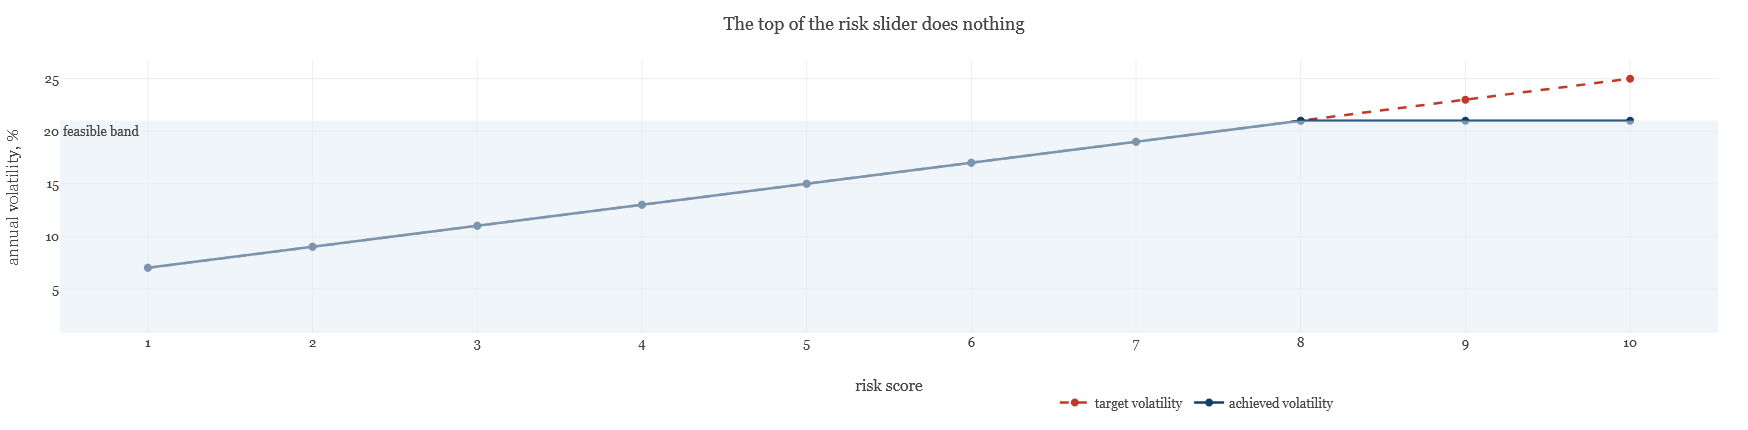

In [7]:
scores = np.arange(1, 11)
targets = 0.20 * (scores / 10) + 0.05
achieved = np.array([portfolio_vol(objective_B(t, MU, COV)) for t in targets])

fig = go.Figure()
fig.add_trace(go.Scatter(x=scores, y=targets * 100, mode='lines+markers', name='target volatility',
                         line=dict(color=RED, width=2.5, dash='dash'), marker=dict(size=8)))
fig.add_trace(go.Scatter(x=scores, y=achieved * 100, mode='lines+markers', name='achieved volatility',
                         line=dict(color=NAVY, width=2.5), marker=dict(size=8)))
fig.add_hrect(y0=vol_floor * 100, y1=vol_ceiling * 100, fillcolor=BAND, opacity=0.5,
              line_width=0, annotation_text='feasible band', annotation_position='top left')
fig.update_layout(template=TEMPLATE, height=430,
                  title_text='The top of the risk slider does nothing',
                  xaxis_title='risk score', yaxis_title='annual volatility, %',
                  xaxis=dict(tickmode='linear', dtick=1),
                  legend=dict(orientation='h', y=-0.2, x=0.6))
fig.show()

The fix is not to widen the asset universe until the target is reachable. It is to map the
risk score onto **percentiles of the feasible band** rather than onto absolute volatility
numbers, so the ladder is defined relative to what the universe can actually deliver. That
single change also makes the ladder robust to changes in the asset menu.

---

## 3 · The estimation problem

Now the substance. Objective C is well-posed, but it takes $\hat\mu$ and $\hat\Sigma$ as inputs,
and those have to come from somewhere. The naive answer is sample moments from historical
returns.

Below we run the honest experiment: draw a return history of $T$ months, estimate, optimise on
the estimates, and then score the resulting portfolio against the **true** parameters. The gap
is the cost of not knowing the truth.

In [8]:
GAMMA_REF = 3.2                       # a median client
w_ideal = optimise(GAMMA_REF)         # what they would hold if we knew the truth
u_ideal = utility(w_ideal, GAMMA_REF)

N_DRAWS = 300
rows = []
concentration_by_T = {}
for T in [36, 60, 120, 240]:
    costs, concentrated, eq = [], 0, []
    for _ in range(N_DRAWS):
        m_hat, S_hat = sample_market(T, rng)
        w = optimise(GAMMA_REF, m_hat, S_hat)
        costs.append((u_ideal - utility(w, GAMMA_REF)) * 1e4)   # bp p.a. under truth
        concentrated += (w.max() > 0.90)
        eq.append(equity_share(w))
    concentration_by_T[T] = np.array(costs)
    rows.append(dict(**{'History': f"{T} months ({T//12} yrs)",
                        'Mean cost (bp p.a.)': f"{np.mean(costs):.0f}",
                        'p90 cost (bp)': f"{np.quantile(costs, 0.9):.0f}",
                        '>90% in one asset': f"{concentrated / N_DRAWS:.0%}",
                        'Equity share sd': f"{np.std(eq):.0%}"}))

print(f"Optimising on sample estimates, then scoring under truth (gamma = {GAMMA_REF}):\n")
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nFor reference, the ideal portfolio holds {equity_share(w_ideal):.0%} equity "
      f"and earns a Sharpe of {portfolio_sharpe(w_ideal):.3f}.")
print(f"An equally weighted portfolio earns {portfolio_sharpe(W_EQUAL):.3f} and costs "
      f"{(u_ideal - utility(W_EQUAL, GAMMA_REF)) * 1e4:.0f} bp.")

Optimising on sample estimates, then scoring under truth (gamma = 3.2):

            History Mean cost (bp p.a.) p90 cost (bp) >90% in one asset Equity share sd
  36 months (3 yrs)                 125           232               53%             42%
  60 months (5 yrs)                 119           228               46%             39%
120 months (10 yrs)                  95           154               30%             36%
240 months (20 yrs)                  72           132               14%             31%

For reference, the ideal portfolio holds 59% equity and earns a Sharpe of 0.314.
An equally weighted portfolio earns 0.299 and costs 13 bp.


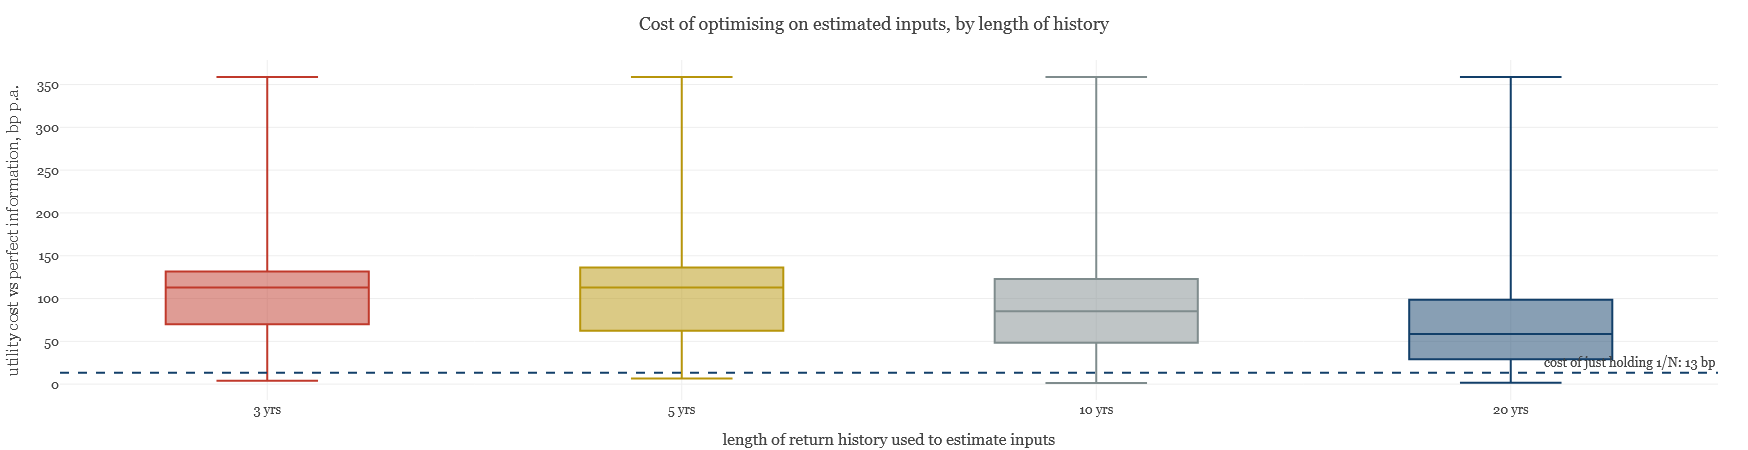

In [9]:
fig = go.Figure()
for T, col in zip([36, 60, 120, 240], [RED, GOLD, GREY, NAVY]):
    c = concentration_by_T[T]
    fig.add_trace(go.Box(y=c, name=f"{T//12} yrs", marker_color=col, boxpoints=False,
                         hovertemplate=f'{T//12}-year history<br>%{{y:.0f}} bp<extra></extra>'))
eq_cost = (u_ideal - utility(W_EQUAL, GAMMA_REF)) * 1e4
fig.add_hline(y=eq_cost, line=dict(color=NAVY, width=2, dash='dash'),
              annotation_text=f'cost of just holding 1/N: {eq_cost:.0f} bp',
              annotation_position='top right')
fig.update_layout(template=TEMPLATE, height=450, showlegend=False,
                  title_text='Cost of optimising on estimated inputs, by length of history',
                  xaxis_title='length of return history used to estimate inputs',
                  yaxis_title='utility cost vs perfect information, bp p.a.')
fig.show()

Read the numbers rather than the shape. Optimising on five years of data costs well over a
hundred basis points a year against knowing the truth, and roughly half of five-year samples
produce a portfolio with more than 90% in a single asset. Twenty years of history — more than
most asset classes have in a usable form, and long enough that the earliest observations
describe a different economy — still leaves a substantial cost and a meaningful concentration
rate.

Now set this against the naive equally weighted portfolio, which requires no estimation at all
and costs 13 bp. Optimising on five years of data costs nine times as much as not optimising.
This is the DeMiguel, Garlappi and Uppal result from Lecture 3 arriving inside a robo-adviser:
the optimiser is not adding value over 1/N, because the inputs it needs are not knowable to the
precision it assumes.

**This is why the inputs are committee-set.** Not because committees are wiser than
estimators, but because a committee produces a stable, defensible, documented number that does
not swing by fifty percentage points when a new quarter of data arrives. It is a variance
reduction device with a governance record attached.

---

## 4 · So: five rungs, or fifty thousand?

We can finally price the ladder. Take the committee's inputs as given — that argument is
settled above — and ask what per-client optimisation would buy.

Each client has their own $\gamma$. Compare two worlds:

* **Bespoke.** Every client's own $\gamma$ goes into Objective C. Fifty thousand optimisations.
* **Ladder.** The optimiser runs $k$ times offline; each client is handed the nearest rung.

The difference, in certainty-equivalent basis points, is what bespoke optimisation is worth.

In [10]:
VAR_EQUITY = 0.16 ** 2
gamma_median = 0.045 / (0.55 * VAR_EQUITY)
client_gamma = np.clip(np.exp(np.log(gamma_median) + 0.42 * rng.normal(size=40_000)), 1.9, 20.0)
sample_clients = rng.choice(client_gamma, 600, replace=False)

def ladder_gap(k, gammas):
    """Bespoke minus nearest-rung, in bp p.a., under committee inputs."""
    rung_gamma = np.quantile(client_gamma, np.linspace(0.05, 0.95, k))
    rung_w = np.array([optimise(g) for g in rung_gamma])
    gaps = []
    for g in gammas:
        w_bespoke = optimise(g)
        w_rung = rung_w[int(np.argmin(np.abs(rung_gamma - g)))]
        gaps.append((utility(w_bespoke, g) - utility(w_rung, g)) * 1e4)
    return np.array(gaps), rung_gamma, rung_w

results = {}
for k in [3, 5, 10, 20]:
    gaps, rg, rw = results.setdefault(k, ladder_gap(k, sample_clients))

print("Value of bespoke optimisation over a k-rung ladder (committee inputs):\n")
print(pd.DataFrame([{'Rungs': k,
                     'Mean gain (bp p.a.)': f"{results[k][0].mean():.2f}",
                     'Median (bp)': f"{np.median(results[k][0]):.2f}",
                     'p90 (bp)': f"{np.quantile(results[k][0], 0.9):.2f}",
                     'Worst client (bp)': f"{results[k][0].max():.1f}"} for k in [3, 5, 10, 20]]
                   ).to_string(index=False))

five_bp = results[5][0].mean()
est_bp  = np.mean(concentration_by_T[60])
print(f"\nGoing bespoke instead of a 5-rung ladder is worth {five_bp:.2f} bp per year.")
print(f"Estimation error in the inputs already costs {est_bp:.0f} bp per year.")
print(f"Ratio: the input problem is {est_bp / five_bp:.0f}x larger than the discretisation problem.")

Value of bespoke optimisation over a k-rung ladder (committee inputs):

 Rungs Mean gain (bp p.a.) Median (bp) p90 (bp) Worst client (bp)
     3                3.05        1.50     8.73              32.9
     5                1.10        0.43     2.00              32.9
    10                0.52        0.08     0.58              32.9
    20                0.41        0.02     0.15              32.9

Going bespoke instead of a 5-rung ladder is worth 1.10 bp per year.
Estimation error in the inputs already costs 119 bp per year.
Ratio: the input problem is 109x larger than the discretisation problem.


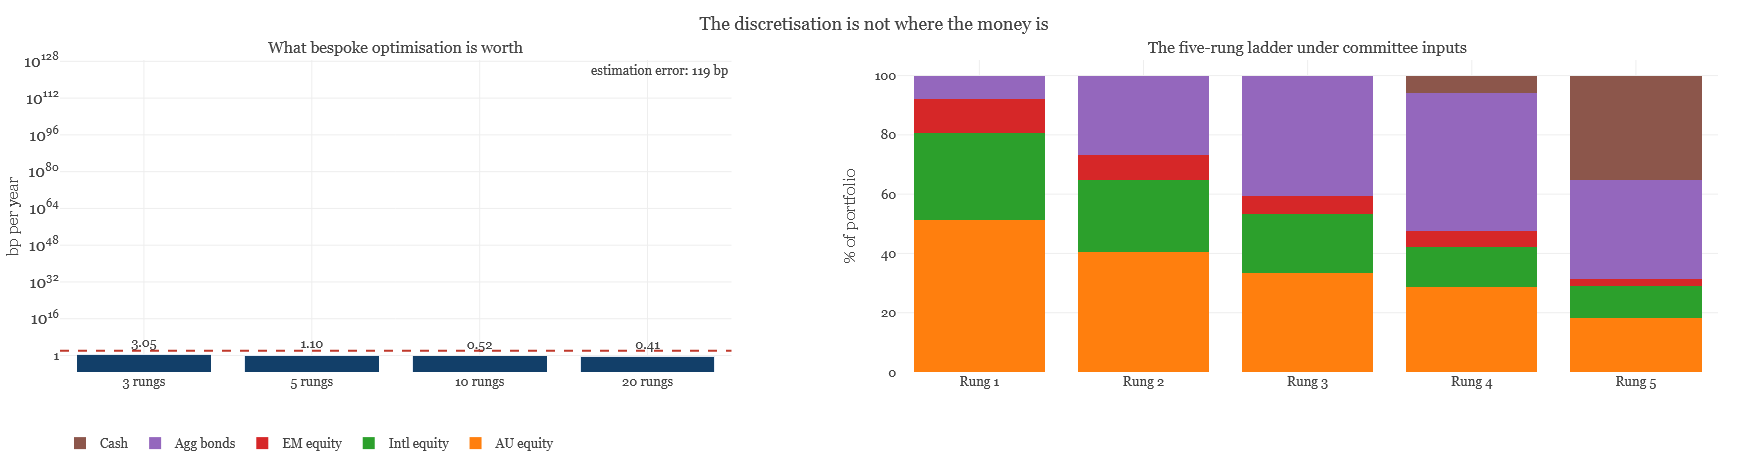

Equity share on each rung: 92%, 73%, 59%, 47%, 31%


In [11]:
fig = make_subplots(rows=1, cols=2, column_widths=[0.45, 0.55], subplot_titles=(
    'What bespoke optimisation is worth', 'The five-rung ladder under committee inputs'))

ks = [3, 5, 10, 20]
fig.add_trace(go.Bar(x=[f"{k} rungs" for k in ks], y=[results[k][0].mean() for k in ks],
                     marker_color=NAVY, text=[f"{results[k][0].mean():.2f}" for k in ks],
                     textposition='outside', showlegend=False,
                     hovertemplate='%{x}<br>%{y:.2f} bp p.a.<extra></extra>'), row=1, col=1)
fig.add_hline(y=est_bp, line=dict(color=RED, width=2, dash='dash'), row=1, col=1,
              annotation_text=f'estimation error: {est_bp:.0f} bp', annotation_position='top right')

_, rg5, rw5 = results[5]
for j, a in enumerate(ASSETS):
    fig.add_trace(go.Bar(x=[f"Rung {i+1}" for i in range(5)], y=rw5[:, j] * 100, name=a,
                         hovertemplate='%{x}<br>' + a + ': %{y:.0f}%<extra></extra>'), row=1, col=2)

fig.update_yaxes(title_text='bp per year', type='log', row=1, col=1)
fig.update_yaxes(title_text='% of portfolio', row=1, col=2)
fig.update_layout(template=TEMPLATE, height=470, barmode='stack',
                  title_text='The discretisation is not where the money is',
                  legend=dict(orientation='h', y=-0.18))
fig.update_traces(marker_line_width=0, row=1, col=2)
fig.show()

print("Equity share on each rung: " +
      ", ".join(f"{equity_share(w):.0%}" for w in rw5))

Two things are worth pausing on.

**The magnitude.** Bespoke optimisation is worth just over one basis point a year against a
five-rung ladder. The estimation error already sitting in the inputs is roughly a hundred times
that. A platform that built per-client continuous optimisation would have solved, at enormous
engineering and governance cost, the smallest problem in its own pipeline. Combined with
notebook 4a, the picture is consistent: the bucketing at the elicitation layer costs about one
and a half basis points, the bucketing at the allocation layer about one, and the inputs more
than a hundred.

**The rungs themselves.** Look at the equity shares the optimiser produces: 92/73/59/47/31.
The conventional retail ladder, hardcoded into the risk-profiling code of essentially every
robo-adviser and every teaching example of one, runs 90/75/60/40/20. The top three rungs agree
to within two percentage points. The bottom two do not — our optimiser wants more equity in the
cautious portfolios than convention allows, because nothing in a pure mean-variance objective
knows about liquidity needs, sequencing risk near retirement, or a cautious client's tolerance
for seeing a red number.

That partial agreement is the honest finding. The conventional table is not a shortcut standing
in for an optimiser; over most of its range it is approximately **what the optimiser returns**
on sensible inputs with long-only constraints. Where it departs, it departs in one direction and
for reasons outside the model — which is worth knowing before you 'correct' it.

**The tail is the exception.** The worst-affected client in each column above is hurt far more
than the average, and it is always the same kind of client: someone whose risk aversion falls
outside the range the rungs were calibrated over. The ladder interpolates well and extrapolates
badly. That is a real design constraint, and it is the honest argument for a sixth rung at each
end rather than for continuous optimisation.

---

## 5 · Where this leaves the thesis

The lecture claims the allocation layer contains no machine learning, and that this is
defensible rather than embarrassing. This notebook supplies the evidence.

The binding constraint at this layer is **not model expressiveness**. It is the precision of
$\hat\mu$. A more flexible model — a neural network mapping client features to weights, a
reinforcement learner tuning allocations — is a way of extracting more structure from the same
inputs. But section 3 shows the inputs do not contain enough signal to justify the structure
the *simple* model already assumes. Added flexibility does not fix an estimation problem; it
amplifies it, which is precisely the finding from Lecture 3.

So the layer stays deliberately simple, and it stays simple for four independent reasons that
all point the same way: the statistics do not support complexity, the regulator requires an
explanation of why this client received this portfolio, the committee process produces a
documented and stable input, and the discretisation you save by going bespoke is worth less
than a basis point.

Machine learning in a robo-adviser lives at the acquisition and behaviour layers, where the
data is plentiful, the feedback loop is short, and the labels are real. Notebook 4e measures
that directly. The middle of the pipeline stays dumb on purpose.

**What this notebook does not show.** Simulated returns are Gaussian, independent across time,
and stationary. Real returns are none of those, and every departure makes the estimation
problem worse rather than better — so the direction of the conclusion is safe, though the
specific basis-point figures are not measurements of any real market. Nor have we tested
shrinkage, factor models, or Black–Litterman, each of which materially improves on sample
moments. Exercise S1 asks you to add one.

---

## Exercises

### Core

**C1 · Kill the slider.** Using a different seed, find a 60-month sample where Objective B puts
every risk profile into a single asset. Report the seed and the asset. Then write the assertion
you would add to a production codebase to catch it, and state where in the deployment pipeline
it should run.

**C2 · Fix the mapping.** Section 2 shows scores 9 and 10 are unreachable. Rewrite the mapping
so the risk score indexes percentiles of the feasible volatility band rather than absolute
volatility. Confirm all ten scores now produce distinct portfolios, and explain what happens to
the ladder when the committee adds a sixth asset class.

**C3 · How many rungs?** Suppose each additional rung costs the platform $40,000 a year in
compliance review, monitoring, and disclosure. With 50,000 clients and an average balance of
$45,000, find the number of rungs that maximises net client benefit. Does your answer explain
what the industry actually offers?

**C4 · Connect the two notebooks.** Notebook 4a produced a distribution of clients across five
buckets. Feed those buckets into this notebook's ladder and report the total cost of the
elicitation and allocation layers together. Which layer would you fund first, and why?

### Stretch

**S1 · Shrinkage.** Implement Ledoit–Wolf shrinkage of the covariance matrix, or simply shrink
$\hat\mu$ toward its grand mean by a factor $\alpha$. Re-run section 3 and plot the cost against
$\alpha$. What is the optimal shrinkage intensity, and how does the cost at that intensity
compare with the value of bespoke optimisation?

**S2 · The 1/N benchmark.** For each history length in section 3, find the shrinkage intensity
at which the optimised portfolio finally beats equal weighting. Is that intensity achievable
with the data a real platform has?

**S3 · Non-Gaussian returns.** Replace `sample_market()` with a bootstrap from a fat-tailed
distribution, or add a regime-switching component. Report how the estimation cost and the
concentration rate change. Does the ladder's advantage grow or shrink?

**S4 · Argue the other side.** Build the strongest case you can that per-client optimisation *is*
worth it — a client population with much wider dispersion in risk aversion, or an asset universe
where the rungs interpolate badly, or a tax overlay that makes each client's problem genuinely
distinct. Quantify it. Then say whether you would fund the project.

---

## Appendix · Reference

**Notation.** $\gamma$ coefficient of risk aversion · $\hat\mu, \hat\Sigma$ estimated inputs ·
$k$ number of rungs · CE certainty-equivalent return.

**The three objectives at a glance.**

| | Form | Hessian | Failure mode |
|---|---|---|---|
| A | $\min (\sqrt{w'\Sigma w} - \sigma_t)^2$ | singular on the target surface | non-unique; answer depends on the starting point |
| B | $\max w'\mu$ s.t. $\sqrt{w'\Sigma w}\le\sigma_t$ | linear objective | corner solution; slider dies when the constraint is slack |
| C | $\max w'\mu - \frac{\gamma}{2}w'\Sigma w$ | $-\gamma\Sigma$, negative definite | none structural; still inherits input error |

**Parameters used.** Five asset classes with the capital market assumptions in section 0;
risk-free rate 3.5% p.a.; long-only and fully invested throughout; client risk aversion
lognormal with median giving 55% equity, log-dispersion 0.42, clipped to $[1.9, 20]$.

**Where this goes next.** Notebook 4c takes the ladder as fixed and asks when to trade back to
it — drift bands against calendar rebalancing, and the turnover the answer costs.